<a href="https://colab.research.google.com/github/adarsh-sirswal/end-to-end-multiclass-dog-image-classifier/blob/main/dog_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# !unzip "drive/MyDrive/Colab Notebooks/dog-vision-project/dog-breed-identification.zip" -d "drive/MyDrive/Colab Notebooks/dog-vision-project/"

# **End-to-end Multi-class Dog Breed Classification**

Building Deep-learning project using Tensorflow 2.0 and Tensorflow Hub.

## 1. Problem

Identification of doog breed using it's image.

## 2. Data

The data is taken from:-
https://www.kaggle.com/c/dog-breed-identification/data

## 3. Evaluation

Evaluation is prediction probabilities for each dog breed in test image.

## 4.Feature

Some information about the data:-
  * Dealing with images (unstructured data).
  * 120 dog breeds (120 different class).
  * 10,000 + training and test data.
  * Training data is labeled and test is not as we have to predict them.

# Getting Workspace ready:-
  * Importing tensorflow
  * Importing tensorflow hub
  * Using GPU (change runtime type)

In [4]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tensorflow_hub as hub

In [5]:
## Importing tensorflow
import tensorflow as tf
print(tf.__version__)

2.20.0


In [6]:
## Checking tensorflow Hub version
import tensorflow_hub as hub
print(hub.__version__)

0.16.1


# Getting data ready (changing data into tensors)
  * tensors are multi-dimensional array of numerical values.



In [7]:
## Importing data-labels

labels_csv = pd.read_csv("drive/MyDrive/Colab Notebooks/dog-vision-project/labels.csv")
print(labels_csv.describe())
print(labels_csv.head())

                                      id               breed
count                              10222               10222
unique                             10222                 120
top     fff43b07992508bc822f33d8ffd902ae  scottish_deerhound
freq                                   1                 126
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever


In [8]:
## Images of each breed
distinct_breeds = labels_csv["breed"].value_counts()
len(distinct_breeds)

120

Text(60.0, 83.0, 'Median Value')

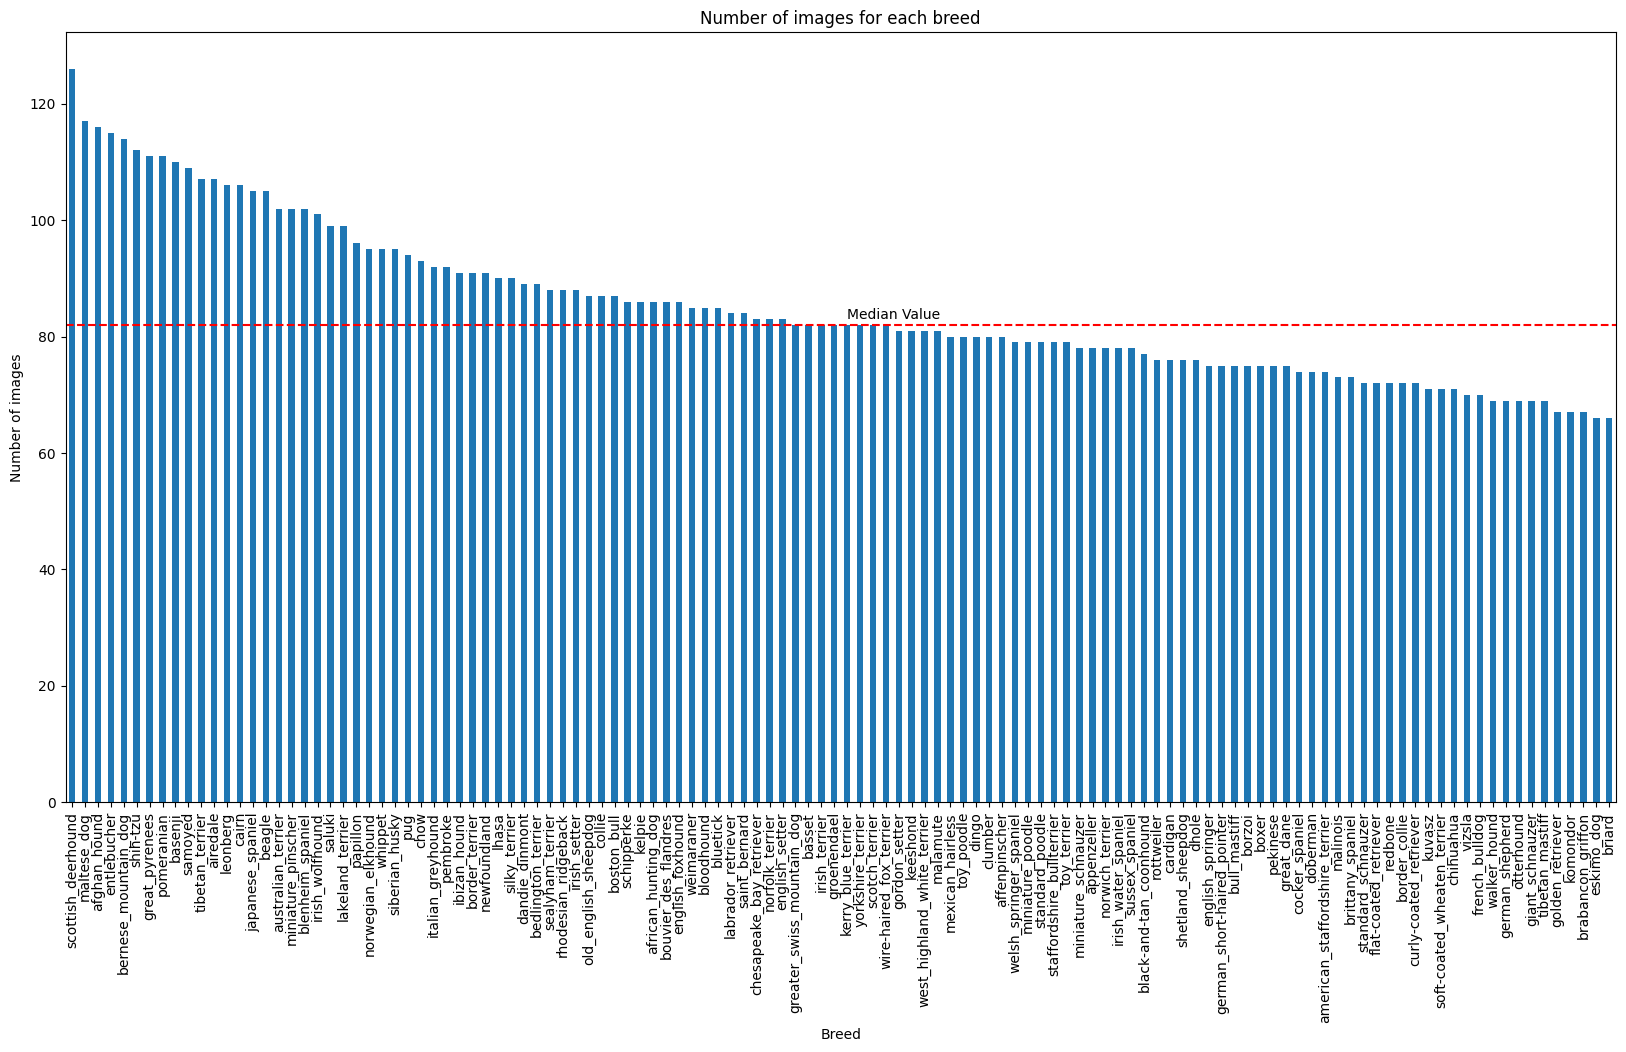

In [9]:
## Plotting
labels_csv["breed"].value_counts().plot.bar(figsize=(20,10));
plt.title("Number of images for each breed");
plt.xlabel("Breed");
plt.ylabel("Number of images");

# Calculate median
median_value = labels_csv.breed.value_counts().median()
# Median line
plt.axhline(
    y=median_value,
    color='red',
    linestyle='--',
    label=f'Median = {median_value}'
)
# Text above median line
plt.text(
    x=len(distinct_breeds)/2,                     # x-position
    y=median_value + 1,      # slightly above line
    s='Median Value',
)

In [10]:
## Median dogs per breed
labels_csv.breed.value_counts().median()

82.0

In [11]:
## Generating File Name
for file_name in labels_csv["id"]:
  print(file_name)

000bec180eb18c7604dcecc8fe0dba07
001513dfcb2ffafc82cccf4d8bbaba97
001cdf01b096e06d78e9e5112d419397
00214f311d5d2247d5dfe4fe24b2303d
0021f9ceb3235effd7fcde7f7538ed62
002211c81b498ef88e1b40b9abf84e1d
00290d3e1fdd27226ba27a8ce248ce85
002a283a315af96eaea0e28e7163b21b
003df8b8a8b05244b1d920bb6cf451f9
0042188c895a2f14ef64a918ed9c7b64
004396df1acd0f1247b740ca2b14616e
0067dc3eab0b3c3ef0439477624d85d6
00693b8bc2470375cc744a6391d397ec
006cc3ddb9dc1bd827479569fcdc52dc
0075dc49dab4024d12fafe67074d8a81
00792e341f3c6eb33663e415d0715370
007b5a16db9d9ff9d7ad39982703e429
007b8a07882822475a4ce6581e70b1f8
007ff9a78eba2aebb558afea3a51c469
008887054b18ba3c7601792b6a453cc3
008b1271ed1addaccf93783b39deab45
008ba178d6dfc1a583617470d19c1673
009509be3ca7cce0ff9e37c8b09b1125
0097c6242c6f3071762d9f85c3ef1b2f
00a338a92e4e7bf543340dc849230e75
00a366d4b4a9bbb6c8a63126697b7656
00a862390341c5be090dd72bd2bc19ef
00b7d114bc5166a629a3cc03d9329120
00ba244566e36e0af3d979320fd3017f
00bee065dcec471f26394855c5c2f3de
00ca187518

In [12]:
## Creating array for path_location for img files.
file_location = ["drive/MyDrive/Colab Notebooks/dog-vision-project/train/" + file_name + ".jpg" for file_name in labels_csv["id"]]
file_location[:10]

['drive/MyDrive/Colab Notebooks/dog-vision-project/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/001cdf01b096e06d78e9e5112d419397.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/002a283a315af96eaea0e28e7163b21b.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/003df8b8a8b05244b1d920bb6cf451f9.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/0042188c895a2f14ef64a918ed9c7b64.jpg']

In [13]:
## Checking if no. of filenames are equal to no. of test files
import os
test_len = len(os.listdir("drive/MyDrive/Colab Notebooks/dog-vision-project/train"))
if test_len == len(labels_csv):
  print("Files in testing and no. of locations are equal.")
else:
  print("Not Equal")

Not Equal


In [14]:
## Creating labels for our dog breeds:-
labels = np.array(labels_csv["breed"])
labels

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'], dtype=object)

In [15]:
## Finding unique_label values
unique_breeds = np.unique(labels)
unique_breeds

array(['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale',
       'american_staffordshire_terrier', 'appenzeller',
       'australian_terrier', 'basenji', 'basset', 'beagle',
       'bedlington_terrier', 'bernese_mountain_dog',
       'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound',
       'bluetick', 'border_collie', 'border_terrier', 'borzoi',
       'boston_bull', 'bouvier_des_flandres', 'boxer',
       'brabancon_griffon', 'briard', 'brittany_spaniel', 'bull_mastiff',
       'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chihuahua',
       'chow', 'clumber', 'cocker_spaniel', 'collie',
       'curly-coated_retriever', 'dandie_dinmont', 'dhole', 'dingo',
       'doberman', 'english_foxhound', 'english_setter',
       'english_springer', 'entlebucher', 'eskimo_dog',
       'flat-coated_retriever', 'french_bulldog', 'german_shepherd',
       'german_short-haired_pointer', 'giant_schnauzer',
       'golden_retriever', 'gordon_setter', 'great_dane',
      

In [16]:
## Turning a single label into array of boolens (true, only when unique_breed matches the label)
# Printing the first label name
labels[0]
# Creating boolean array where its name matches the unique breed array
labels[0] == unique_breeds

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [17]:
## Turning every label into boolean array
boolean_labels = [label == np.array(unique_breeds) for label in labels]
# Viewing first 2 boolean arrays
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [18]:
## Turning boolean array into integers
print(labels[0])    # Orignal label
print(np.where(unique_breeds == labels[0]))    # Index where label occurs
print(boolean_labels[0].argmax())
print(boolean_labels[0].astype(int))

boston_bull
(array([19]),)
19
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


# Creating a Validation set
Since, kaggle doesn't provide one.

In [19]:
## Setting up X and y variables
X = file_location
y = boolean_labels

Starting off experiment with less samples.

In [20]:
## This slider feature is available in google colab
NUM_IMAGES =  1000 #@param {type:"slider", min:1000, max:10000}

In [21]:
## Splitting data into training and validation set.
from sklearn.model_selection import train_test_split

## Splitting into train and validation set.
X_train, X_val, y_train, y_val = train_test_split(X[:NUM_IMAGES],
                                                  y[:NUM_IMAGES],
                                                  random_state=42, test_size=0.2)
len(X_train), len(X_val), len(y_train), len(y_val)

(800, 200, 800, 200)

# Preprocessing images
For preprocessing, we are going to do somethings:-
  * Take image file path as input.
  * Use tensorflow to read the file and save it as `image`.
  * Turn `image` to tensor (jpg).
  * Resize `image` to (224,224).
  * Return modified image.

In [22]:
## Converting image to nparray
from matplotlib.pyplot import imread   ## imread is used to read an image, and convert it into numpy array.
image = imread(file_location[29])
image.shape   ## (height, width, channel (3 for rgb)/ (4 for rgba)).

(375, 500, 3)

array([[[ 10,  11,  15],
        [ 14,  15,  19],
        [ 17,  18,  22],
        ...,
        [ 15,  12,   5],
        [ 23,  20,  13],
        [ 27,  24,  17]],

       [[ 12,  13,  17],
        [ 11,  12,  14],
        [ 10,  11,  15],
        ...,
        [ 22,  19,  14],
        [ 20,  17,  12],
        [ 26,  23,  18]],

       [[ 13,  14,  16],
        [  9,  11,  10],
        [  6,   7,   9],
        ...,
        [ 17,  13,  12],
        [  3,   0,   0],
        [  3,   0,   0]],

       ...,

       [[104,  90,  61],
        [119, 105,  76],
        [143, 126,  98],
        ...,
        [164, 147, 129],
        [160, 143, 125],
        [161, 144, 126]],

       [[111,  97,  68],
        [125, 111,  82],
        [132, 115,  87],
        ...,
        [147, 130, 112],
        [150, 133, 115],
        [154, 137, 119]],

       [[120, 106,  77],
        [147, 133, 104],
        [134, 117,  89],
        ...,
        [130, 113,  95],
        [136, 119, 101],
        [140, 123, 105]]], dtype=uint8)
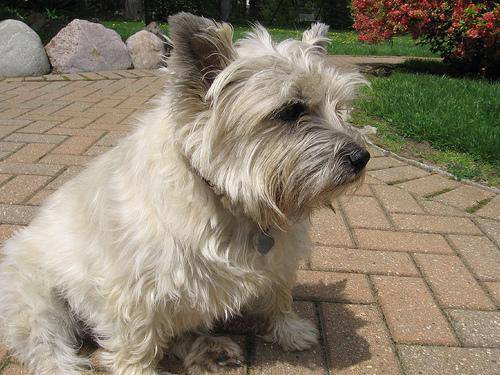

In [23]:
image ## ndarray containing values from 0 to 255.

In [24]:

image.max(), image.min()

(np.uint8(255), np.uint8(0))

# Why is image converted to Tensors for preprocessing?
* GPU Acceleration and Parallel Processing: Tensors allow for efficient parallel computation on GPUs (or TPUs), making it possible to process large batches of images simultaneously rather than sequentially.

* Standardized Format for Neural Networks: Neural networks (like CNNs) are built to process tensors as inputs, performing operations on these numerical structures to learn patterns and predict outputs.

* So, we turn our batches into size of `32`.

* We, convert image into the format of :
      `(label, image)`


In [25]:
IMG_SIZE = 224

def process_image(file_location, img_size=IMG_SIZE):
  '''
        Takes file location and returns them in tensors.
  '''
  ## Reading img file.
  image = tf.io.read_file(file_location)
  ## Turning jpeg into tensor, with 3 colour channels. (r,g,b).
  image = tf.image.decode_jpeg(image, channels=3)
  ## Converting colour channel value from 0-255 to 0-1.
  image = tf.image.convert_image_dtype(image, tf.float32)
  ## Resizing image into desired value (224,224).
  image = tf.image.resize(image, size=[IMG_SIZE, IMG_SIZE])

  return image

## Turning data into batches

WHY?
1. Memory Efficiency
2. 2. Faster Training with GPUs

  * GPUs are optimized for parallel computation. Matrix operations become massively faster in batches.

3. TensorFlow Pipelines Are Built Around Batches

In [26]:
def get_image_label(file_location, label):
  '''
      Takes file location and label and returns them in tensors.
  '''
  image = process_image(file_location)
  return image, label

In [27]:
## DEMO of the above.
get_image_label(X[42], tf.constant(y[42]))  ## Used, tf.constant(), to convert boolean labels into tensors.

(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
 array([[[0.3264178 , 0.5222886 , 0.3232816 ],
         [0.2537167 , 0.44366494, 0.24117759],
         [0.25699762, 0.4467087 , 0.23893751],
         ...,
         [0.29325107, 0.5189916 , 0.3215547 ],
         [0.29721776, 0.52466875, 0.33030328],
         [0.2948505 , 0.5223015 , 0.33406618]],
 
        [[0.25903144, 0.4537807 , 0.27294815],
         [0.24375686, 0.4407019 , 0.2554778 ],
         [0.2838985 , 0.47213382, 0.28298813],
         ...,
         [0.2785345 , 0.5027992 , 0.31004712],
         [0.28428748, 0.5108719 , 0.32523635],
         [0.28821915, 0.5148036 , 0.32916805]],
 
        [[0.20941195, 0.40692952, 0.25792548],
         [0.24045378, 0.43900946, 0.2868911 ],
         [0.29001117, 0.47937486, 0.32247734],
         ...,
         [0.26074055, 0.48414773, 0.30125174],
         [0.27101526, 0.49454468, 0.32096273],
         [0.27939945, 0.5029289 , 0.32934693]],
 
        ...,
 
        [[0.00634795, 0.03442048

Since we got a way to turn our data into tuples of `(image, label)`, so now we make a function to turn all our data (X and y) and divide them into batches of 32.

In [28]:
BATCH_SIZE = 32

## function to turn data into batches
def create_data_batches(X, y=None, batch_size=BATCH_SIZE, valid_data=False, test_data=False):
  '''
      Creates batches of data out of image (X) and label (y) pairs.
      Shuffles the data if it's training data but doesn't shuffle it if it's validation data.
      Also accepts test data as input (no labels).
  '''
  ## If the data is test data, we dont have labels
  if test_data:
    print("Creating test data batches...")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X)))  ## Here, tf.constant converts data to tensors. (only filepath given, no labels)
    data_batch = data.map(process_image).batch(BATCH_SIZE)
    return data_batch

  ## If its valid dataset, we dont shuffle it
  elif valid_data:
    print("Creating validation data batches...")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X), tf.constant(y)))  ## (filepaths, labels)
    data_batch = data.map(get_image_label).batch(BATCH_SIZE)
    return data_batch

  else:
    print("Creating training data batches...")
    ## If its training data, we shuffle it.. Firstly turning the filepath and labels into tensors
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X), tf.constant(y)))  ## (filepaths, labels)

    ## Shuffling data (filepath and labels) before mapping
    data = data.shuffle(buffer_size=len(X))

    ## Creatu=ing tuples of (image, label) (preprossing image)
    data_batch = data.map(get_image_label)

    ## Turning training data into batches.
    data_batch = data.batch(BATCH_SIZE)

  return data_batch

In [29]:
## Creating training and validation data batches..
train_data = create_data_batches(X_train, y_train)
val_data = create_data_batches(X_val, y_val, valid_data=True)

Creating training data batches...
Creating validation data batches...


In [30]:
## Checking different atributes of our data
train_data.element_spec, val_data.element_spec

((TensorSpec(shape=(None,), dtype=tf.string, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)),
 (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)))

# Visualizing Our Data

In [31]:
import matplotlib.pyplot as plt

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def show_25_images(images, labels):

    plt.figure(figsize=(15, 15))

    for i in range(25):

        # Convert byte path to normal string
        image_path = images[i].decode("utf-8")

        # Add /content because you're using Google Colab
        image_path = "/content/" + image_path

        # Load the image
        image = Image.open(image_path)

        # Get the class index
        label_index = np.argmax(labels[i])

        # Get the breed name
        label_name = unique_breeds[label_index]

        # Display image
        plt.subplot(5, 5, i + 1)
        plt.imshow(image)

        # Display breed name
        plt.title(label_name)

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [33]:
train_data

<_BatchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [34]:
train_images, train_labels = next(train_data.as_numpy_iterator())
train_images, train_labels

(array([b'drive/MyDrive/Colab Notebooks/dog-vision-project/train/056b535b441278e83839984f1b1da0a6.jpg',
        b'drive/MyDrive/Colab Notebooks/dog-vision-project/train/106a740e7e34d80e35b0f40a3d96fc1b.jpg',
        b'drive/MyDrive/Colab Notebooks/dog-vision-project/train/1043003fb33c5fa1d094cde3c0dd1fd5.jpg',
        b'drive/MyDrive/Colab Notebooks/dog-vision-project/train/0440acb104d7346ccc9bba0716603f6a.jpg',
        b'drive/MyDrive/Colab Notebooks/dog-vision-project/train/0d8858e722c5f9834ddbdcecbf3cd4d6.jpg',
        b'drive/MyDrive/Colab Notebooks/dog-vision-project/train/0b5604e1cdfcb595ceb36424126a3e09.jpg',
        b'drive/MyDrive/Colab Notebooks/dog-vision-project/train/0dd7b725203b91c30ca4f796d168e6ba.jpg',
        b'drive/MyDrive/Colab Notebooks/dog-vision-project/train/0f73c1cc99dd8b9c580c4260debf1f93.jpg',
        b'drive/MyDrive/Colab Notebooks/dog-vision-project/train/146c8ed2e65ed9e04d8302bf1d96815a.jpg',
        b'drive/MyDrive/Colab Notebooks/dog-vision-project/train

In [35]:
print(type(train_data))

<class 'tensorflow.python.data.ops.batch_op._BatchDataset'>


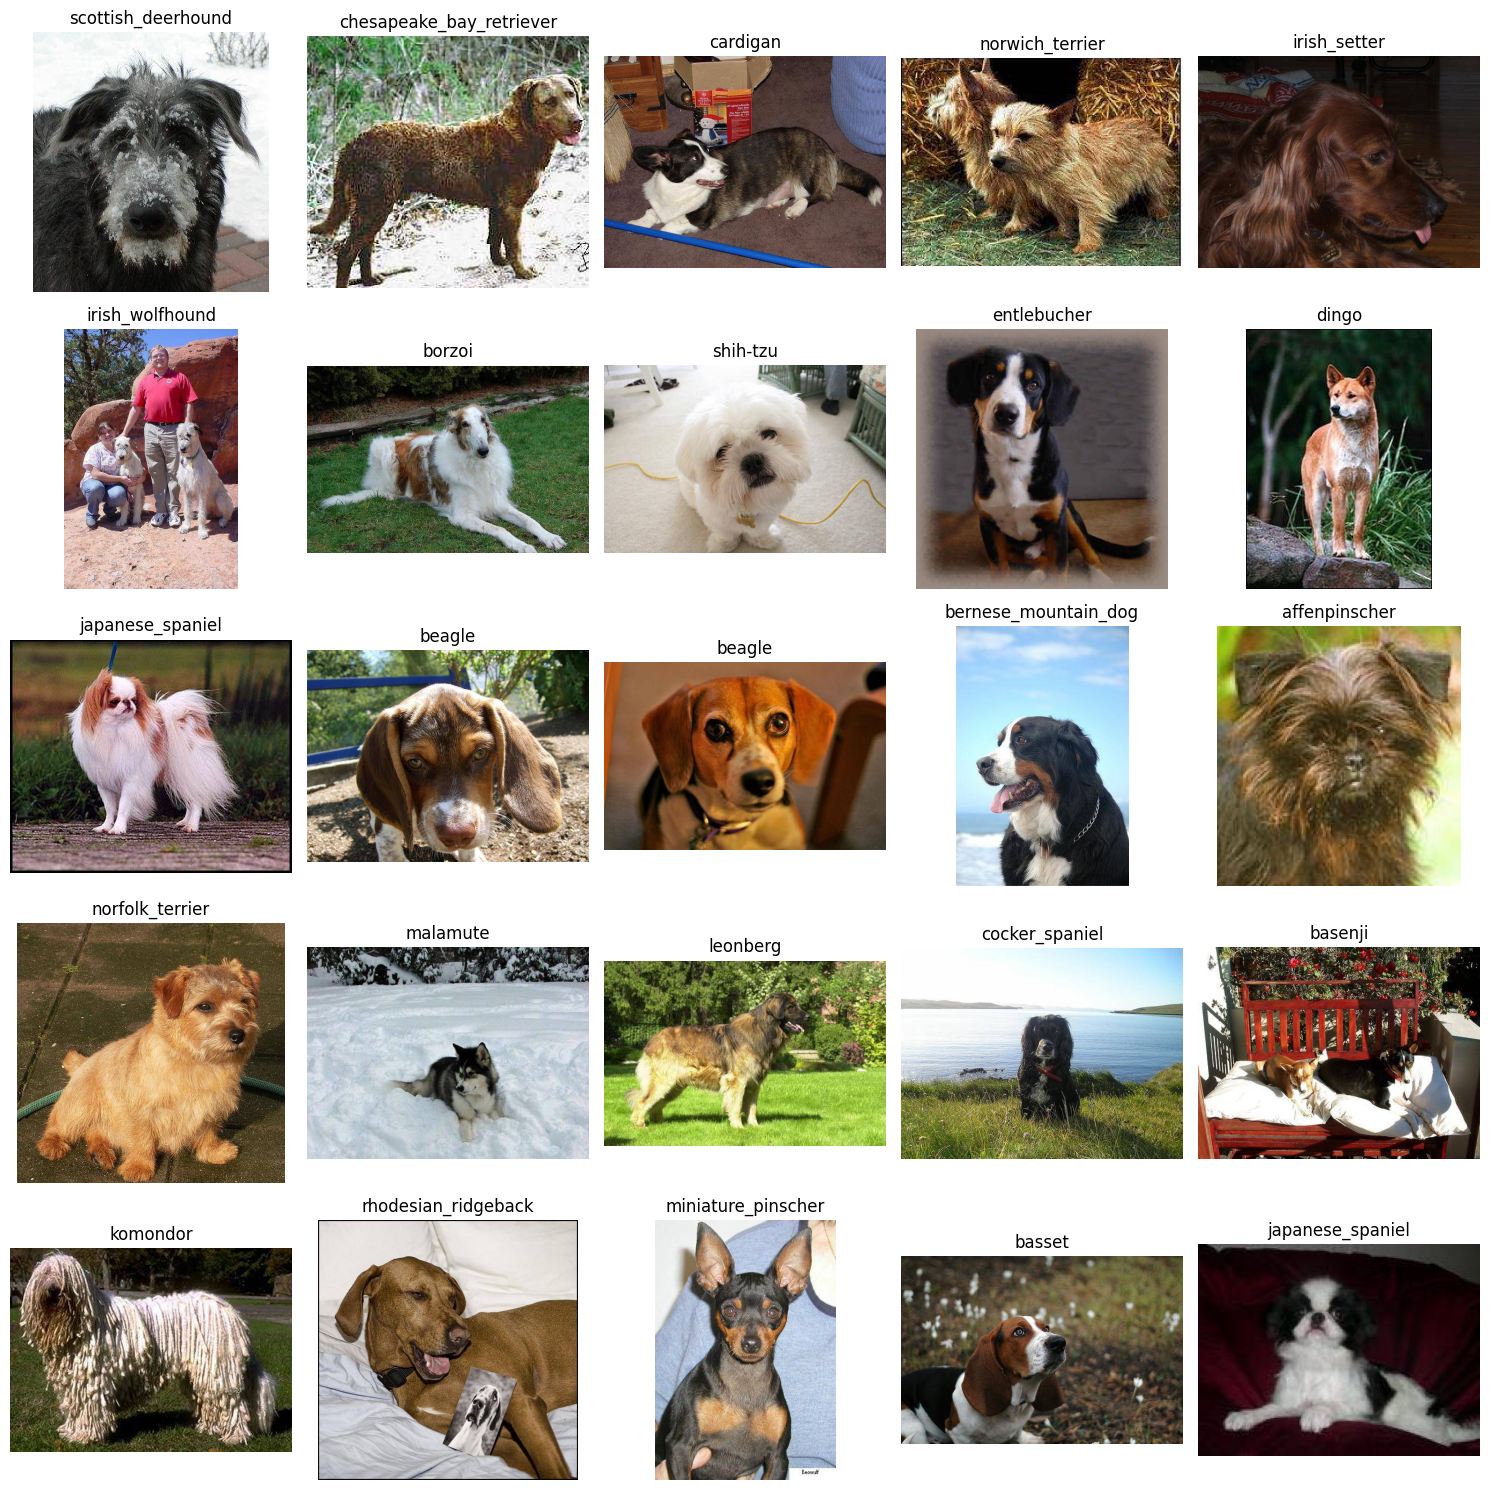

In [36]:
show_25_images(train_images, train_labels)

# Building a Model

Before building, we need to define certain things.

* Input shape, image shape in form of tensors.
* Output shape, image labels in form of tensors.
* URL of model, we are gonna use.

In [37]:
IMG_SIZE

224

In [38]:
## Input shape to model.
INPUT_SHAPE = [None, IMG_SIZE, IMG_SIZE, 3]  # Batch, height, width, colour channel.

## Output shape to model.
OUTPUT_SHAPE = len(unique_breeds)

## Model Setup from Tensorflow Hub
MODEL_URL = "https://www.kaggle.com/models/keras/efficientnetv2"

In [39]:
# !pip install -q tf-keras tensorflow-hub

In [40]:
def create_model(
    input_shape=INPUT_SHAPE,
    output_shape=OUTPUT_SHAPE
):

    # Setting up EfficientNetV2B0
    print("Building EfficientNetV2B0 model...")

    base_model = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Freeze the pretrained layers
    base_model.trainable = False

    # Create the model
    model = tf.keras.Sequential([
        base_model,

        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(
            units=output_shape,
            activation="softmax"
        )
    ])

    # Compile the model
    model.compile(
        loss=tf.keras.losses.CategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.Adam(),
        metrics=["accuracy"]
    )

    # Build the model
    model.build(input_shape)

    return model

In [41]:
model = create_model()
model.summary()

Building EfficientNetV2B0 model...
24274472/24274472 [==============================] - 2s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-b0 (Functio  (None, 7, 7, 1280)        5919312   
 nal)                                                            
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 120)               153720    
                                                                 
Total params: 6073032 (23.17 MB)
Trainable params: 153720 (600.47 KB)
Non-trainable para

### Creating Tensorflow Callbacks

Callbacks, are helper functions, that a model uses, during training, to save and check its progress. Also it is used to prevent overfitting.

So, we will create 2 callbacks, one to track our model progress and another for early stopping, to prevent our model from trainin for too long.

#### TensorBoard Callbacks

In [42]:
## Loading tensorboard notebook extension
%load_ext tensorboard

In [43]:
import datetime

def create_tensorboard_callback():
  ## Creating lod directory to store Tensorboard logs
  logdir = os.path.join("/content/drive/MyDrive/Colab Notebooks/dog-vision-project/logs",

                        ## Making it so, the logs get tracked
                        datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

  return tf.keras.callbacks.TensorBoard(logdir)

### Early stopping Callback
It helps stop our model from overfitting, by stopping training if a certain evaluation metric stops improving.

In [44]:
### Creating early stopping callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy",patience=3)

### Training a model (on subset of data)

Initially our model will train on 1000 images, to make sure everything is working.

In [45]:
NUM_EPOCHS = 100 #@param {type:"slider", min:10, max:100, step:10}

#### Creating a function that trains a model.

* Create a model using `create_model()`.
* Setup tensorboard callback.
* Call the fit function on our model, passing it training data, validation data, number of epochs to train for.
* Return the model.

In [47]:
# Build a function to train and return a trained model
def train_model():
  """
  Trains a given model and returns the trained version.
  """
  # Create a model
  model = create_model()

  # Create new TensorBoard session everytime we train a model
  tensorboard = create_tensorboard_callback()

  # Fit the model to the data passing it the callbacks we created
  model.fit(x=train_data,
            epochs=NUM_EPOCHS,
            validation_data=val_data,
            validation_freq=1,
            callbacks=[tensorboard, early_stopping])
  # Return the fitted model
  return model

In [51]:
# Fit the model to the data
model = train_model()

Building EfficientNetV2B0 model...
Epoch 1/100


UnimplementedError: Graph execution error:

Detected at node sequential_3/Cast defined at (most recent call last):
  File "<frozen runpy>", line 203, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.13/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.13/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.13/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.13/asyncio/base_events.py", line 684, in run_forever

  File "/usr/lib/python3.13/asyncio/base_events.py", line 2061, in _run_once

  File "/usr/lib/python3.13/asyncio/events.py", line 89, in _run

  File "/usr/local/lib/python3.13/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.13/dist-packages/ipyk